In [ ]:
%run figure_5_1_case_study(1).py

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, os

df = pd.read_csv(r"C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\df_macro_augmented.csv")

COUNTRIES, YEARS = ['GBR','SWE','ESP'], [2004,2005,2006]
subset = df[df['iso'].isin(COUNTRIES) & df['year'].isin(YEARS)]

data = {}
for c in COUNTRIES:
    s = subset[subset['iso']==c]
    data[c] = {
        'credit_raw':  round(s['tloans_gr_lag1'].mean()*100,1),
        'credit_dm':   round(s['tloans_gr_lag1_dm'].mean(),3),
        'hp_raw':      round(s['hpnom_gr_lag1'].mean()*100,1),
        'ts_dm':       round(s['term_spread_lag1_dm'].mean(),3),
        'stir_dm':     round(s['stir_lag1_dm'].mean(),3),
    }

KEYS = ['credit_raw','credit_dm','hp_raw','ts_dm','stir_dm']
TITLES = ['Credit growth\nraw (% p.a.)','Credit growth\ndemeaned',
          'House price growth\nraw (% p.a.)','Term spread lag1\ndemeaned (pp)',
          'Short-term rate lag1\ndemeaned (pp)']
COLORS = {'ESP':'#2166ac','SWE':'#4dac26','GBR':'#d01c8b'}
LEGEND = {'ESP':'Spain (ESP) — correct hit',
          'SWE':'Sweden (SWE) — true positive\u2020',
          'GBR':'UK (GBR) — false negative'}

fig, axes = plt.subplots(1,5,figsize=(15,5.5))
fig.patch.set_facecolor('white')
x, WIDTH = np.array([0,1,2]), 0.55

for ax, key, title in zip(axes, KEYS, TITLES):
    vals = [data['ESP'][key], data['SWE'][key], data['GBR'][key]]
    bars = ax.bar(x, vals, color=[COLORS['ESP'],COLORS['SWE'],COLORS['GBR']],
                  width=WIDTH, edgecolor='white')
    ax.axhline(0, color='#333333', linewidth=0.75)
    ax.set_xticks(x); ax.set_xticklabels(['ESP','SWE','GBR'], fontsize=10)
    ax.set_title(title, fontsize=9.5, fontweight='bold', pad=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    vr = max(abs(v) for v in vals) or 1
    for bar, val in zip(bars, vals):
        fmt = f'{val:.1f}' if abs(val)>=1 else f'{val:.3f}'
        ax.text(bar.get_x()+bar.get_width()/2,
                val+0.05*vr if val>=0 else val-0.05*vr, fmt,
                ha='center', va='bottom' if val>=0 else 'top',
                fontsize=8.5, fontweight='bold')

patches = [mpatches.Patch(color=COLORS[c], label=LEGEND[c]) for c in ['ESP','SWE','GBR']]
fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5,-0.05), frameon=False)
fig.text(0.01,-0.10,
         '\u2020 Sweden: JST records crisis onset 2008 (target_h2=1 in 2007). '
         'Mechanism: contagion, not domestic credit boom.',
         fontsize=8.5, color='#555555', style='italic')
fig.suptitle('Figure 5.1. Key macro-financial features: Spain, Sweden, UK — 2004-2006 averages.\n'
             'Panels 1,3: raw %. Panels 2,4,5: demeaned from expanding country means. Source: JST R6.',
             fontsize=9.5, y=1.05)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/figure_5_1_case_study_features.png", dpi=200,
            bbox_inches='tight', facecolor='white')
print("Saved to figures/figure_5_1_case_study_features.png")
plt.show()

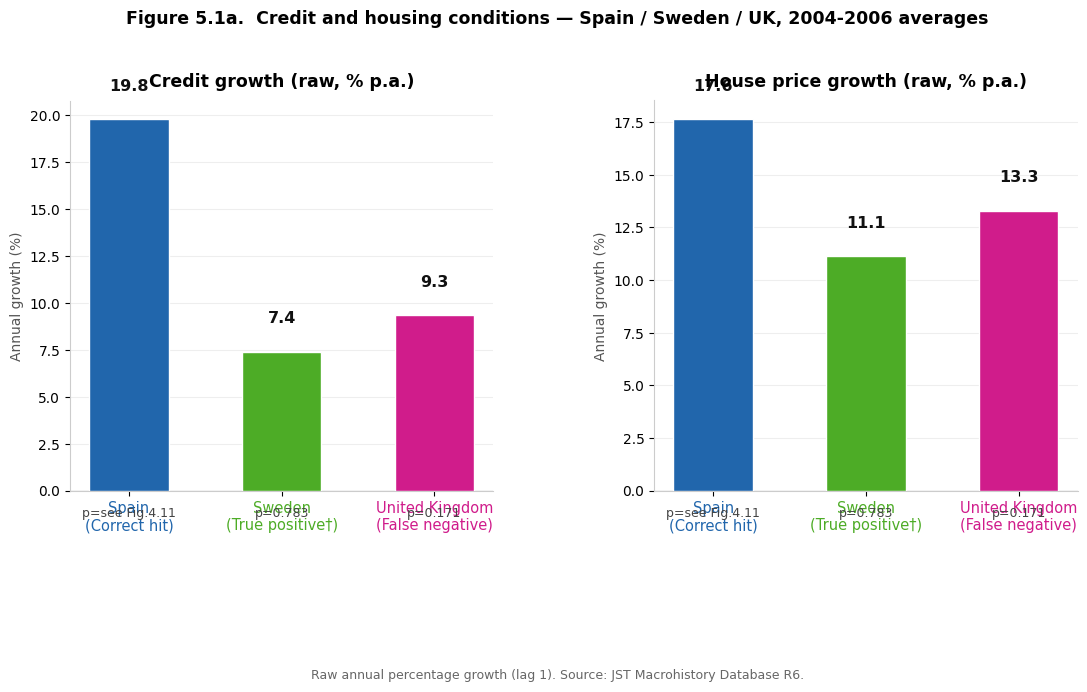

Figure 5.1a saved.


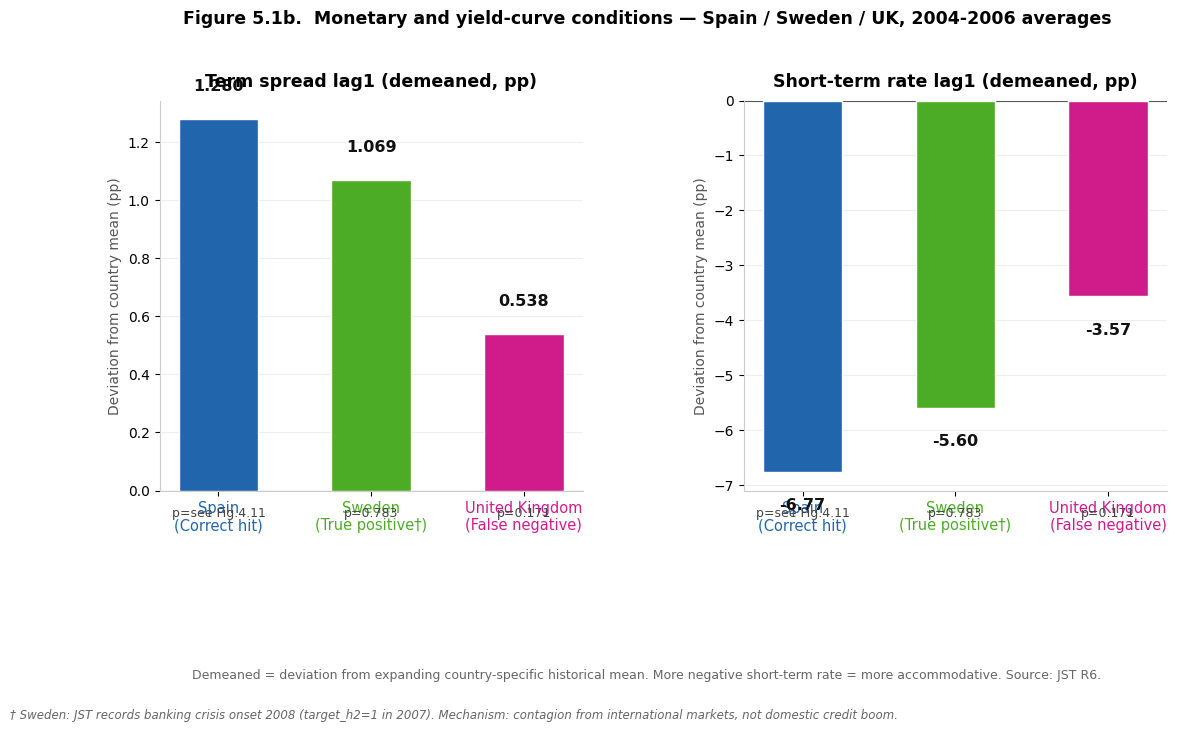

Figure 5.1b saved to figures/ folder.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

df = pd.read_csv(r"C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\df_macro_augmented.csv")
subset = df[df['iso'].isin(['GBR','SWE','ESP']) & df['year'].isin([2004,2005,2006])]

vals = {}
for c in ['ESP','SWE','GBR']:
    s = subset[subset['iso']==c]
    vals[c] = {'credit': s['tloans_gr_lag1'].mean()*100,
               'hp':     s['hpnom_gr_lag1'].mean()*100,
               'ts':     s['term_spread_lag1_dm'].mean(),
               'stir':   s['stir_lag1_dm'].mean()}

NAMES  = ['Spain','Sweden','United Kingdom']
ISOS   = ['ESP','SWE','GBR']
ROLES  = ['Correct hit','True positive†','False negative']
COLORS = ['#2166ac','#4dac26','#d01c8b']
PROBS  = ['see Fig.4.11','0.783','0.171']
X, W   = np.arange(3), 0.52

def panel(ax, key, title, ylabel, fmt='.1f'):
    data = [vals[c][key] for c in ISOS]
    bars = ax.bar(X, data, width=W, color=COLORS, edgecolor='white', zorder=3)
    ax.axhline(0, color='#555', linewidth=0.8, zorder=2)
    ax.set_xticks(X)
    ax.set_xticklabels([f'{n}\n({r})' for n,r in zip(NAMES,ROLES)], fontsize=10.5)
    for tick,col in zip(ax.get_xticklabels(), COLORS): tick.set_color(col)
    ax.set_title(title, fontsize=12.5, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10, color='#555')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#ccc'); ax.spines['bottom'].set_color('#ccc')
    ax.yaxis.grid(True, color='#eee', zorder=0); ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=10)
    vr = max(abs(v) for v in data) or 1
    for bar,val,prob in zip(bars,data,PROBS):
        ypos = val+0.07*vr if val>=0 else val-0.07*vr
        ax.text(bar.get_x()+bar.get_width()/2, ypos, f'{val:{fmt}}',
                ha='center', va='bottom' if val>=0 else 'top',
                fontsize=11.5, fontweight='bold', color='#111')
        ax.annotate(f'p={prob}',
            xy=(bar.get_x()+bar.get_width()/2, ax.get_ylim()[0]),
            xytext=(bar.get_x()+bar.get_width()/2, ax.get_ylim()[0]-0.04*abs(ax.get_ylim()[1]-ax.get_ylim()[0])),
            ha='center', va='top', fontsize=9, color='#444', annotation_clip=False)

os.makedirs('figures', exist_ok=True)

# Figure 5.1a — Credit & Housing
figA,(ax1,ax2) = plt.subplots(1,2,figsize=(13,6.5))
figA.patch.set_facecolor('white')
figA.subplots_adjust(wspace=0.38, bottom=0.28)
panel(ax1,'credit','Credit growth (raw, % p.a.)','Annual growth (%)')
panel(ax2,'hp','House price growth (raw, % p.a.)','Annual growth (%)')
figA.suptitle('Figure 5.1a.  Credit and housing conditions — Spain / Sweden / UK, 2004-2006 averages', fontsize=12.5, fontweight='bold', y=1.02)
figA.text(0.5,-0.01,'Raw annual percentage growth (lag 1). Source: JST Macrohistory Database R6.', ha='center', fontsize=9, color='#666')
figA.savefig('figures/figure_5_1a.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 5.1a saved.')

# Figure 5.1b — Monetary & Yield
figB,(ax3,ax4) = plt.subplots(1,2,figsize=(13,6.5))
figB.patch.set_facecolor('white')
figB.subplots_adjust(wspace=0.38, bottom=0.28)
panel(ax3,'ts','Term spread lag1 (demeaned, pp)','Deviation from country mean (pp)',fmt='.3f')
panel(ax4,'stir','Short-term rate lag1 (demeaned, pp)','Deviation from country mean (pp)',fmt='.2f')
figB.suptitle('Figure 5.1b.  Monetary and yield-curve conditions — Spain / Sweden / UK, 2004-2006 averages', fontsize=12.5, fontweight='bold', y=1.02)
figB.text(0.5,-0.01,'Demeaned = deviation from expanding country-specific historical mean. More negative short-term rate = more accommodative. Source: JST R6.', ha='center', fontsize=9, color='#666')
figB.text(0.01,-0.07,'† Sweden: JST records banking crisis onset 2008 (target_h2=1 in 2007). Mechanism: contagion from international markets, not domestic credit boom.', fontsize=8.5, color='#666', style='italic')
figB.savefig('figures/figure_5_1b.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 5.1b saved to figures/ folder.')